# 01 — EDA: Histórico de Inventarios Herdez

Análisis exploratorio independiente para verificar los hallazgos documentados en `CLAUDE.md`.

**Objetivo:** Reproducir cada afirmación del CLAUDE.md con datos reales y reportar coincidencias/discrepancias.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
from sklearn.metrics import mutual_info_score

# Detectar raíz del proyecto (funciona desde notebooks/ y desde raíz)
PROJECT_ROOT = Path("..") if Path("../pyproject.toml").exists() else Path(".")
EXCEL_PATH = PROJECT_ROOT / "data" / "raw" / "herdez_inventario.xlsx.xlsx"

df = pd.read_excel(EXCEL_PATH, sheet_name="Historico_Inventarios")
df["Fecha"] = pd.to_datetime(df["Fecha"])

print(f"Shape: {df.shape}")
print(f"Rango fechas: {df['Fecha'].min().date()} -> {df['Fecha'].max().date()}")
print(f"SKUs: {df['SKU_ID'].nunique()}, CEDIs: {df['CEDI'].nunique()}")
print(f"Nulls totales: {df.isnull().sum().sum()}")

# Pre-calcular target para secciones posteriores
df_sorted = df.sort_values(["SKU_ID", "CEDI", "Fecha"]).reset_index(drop=True)
df_sorted["ventas_rolling_7d"] = (
    df_sorted.groupby(["SKU_ID", "CEDI"])["Ventas_Unidades"]
    .transform(lambda x: x.rolling(7, min_periods=7).mean())
)
df_sorted["quiebre_proyectado"] = (
    (df_sorted["Stock_Actual"] - df_sorted["ventas_rolling_7d"] * 5) < 0
).astype(int)
df_t = df_sorted.dropna(subset=["ventas_rolling_7d"]).reset_index(drop=True)

df.head()

Shape: (1200, 11)
Rango fechas: 2024-03-01 -> 2024-04-29
SKUs: 5, CEDIs: 4
Nulls totales: 0


,Fecha,SKU_ID,CEDI,Ventas_Unidades,Stock_Actual,Lead_Time_Dias,Promocion_Activa,Precio_Combustible_MXN,Clima,Costo_Quiebre_Stock_Diario,Costo_Transferencia_Unidad
0,2024-03-01,HZ-Salsa-Verde-200g,CEDI_Norte,195,1180,3,0,22.90,Despejado,15000,12.64
1,2024-03-01,HZ-Salsa-Verde-200g,CEDI_Sur,198,921,5,0,23.27,Despejado,15000,11.04
2,2024-03-01,HZ-Salsa-Verde-200g,CEDI_Occidente,185,71,5,0,23.51,Despejado,15000,10.07
3,2024-03-01,HZ-Salsa-Verde-200g,CEDI_Bajio,188,1007,5,0,24.78,Despejado,15000,10.89
4,2024-03-01,HZ-Salsa-Roja-200g,CEDI_Norte,204,216,3,0,23.55,Despejado,15000,11.16


## 1. Promocion_Activa: tiene senal predictiva?

**CLAUDE.md dice:** ventas con promo (137.5) <= sin promo (140.5) -> sin senal.

Analisis mejorado: tests formales + evaluacion contra el **target real** (`quiebre_proyectado`), no solo contra ventas.

In [2]:
# --- vs Ventas (analisis original mejorado) ---
promo_0 = df[df["Promocion_Activa"] == 0]["Ventas_Unidades"]
promo_1 = df[df["Promocion_Activa"] == 1]["Ventas_Unidades"]
print("=== Promo vs Ventas ===")
print(f"Sin promo: n={len(promo_0)}, mean={promo_0.mean():.2f}, std={promo_0.std():.2f}")
print(f"Con promo: n={len(promo_1)}, mean={promo_1.mean():.2f}, std={promo_1.std():.2f}")
print(f"Cohen's d: {(promo_1.mean() - promo_0.mean()) / df['Ventas_Unidades'].std():.4f}")

t_stat, p_val = stats.ttest_ind(promo_0, promo_1, equal_var=False)
print(f"Welch t-test: t={t_stat:.4f}, p={p_val:.4f}")

# --- vs Target (lo que realmente importa) ---
print("\n=== Promo vs Quiebre (target real) ===")
ct = pd.crosstab(df_t["Promocion_Activa"], df_t["quiebre_proyectado"])
print(ct)
chi2, p_chi, dof, _ = stats.chi2_contingency(ct)
mi = mutual_info_score(df_t["Promocion_Activa"], df_t["quiebre_proyectado"])
print(f"Chi2={chi2:.4f}, p={p_chi:.4f}")
print(f"Mutual Information: {mi:.6f} (despreciable)")
print(f"\nTasa quiebre sin promo: {df_t[df_t['Promocion_Activa']==0]['quiebre_proyectado'].mean():.3f}")
print(f"Tasa quiebre con promo: {df_t[df_t['Promocion_Activa']==1]['quiebre_proyectado'].mean():.3f}")
print(f"\nConclusion: diferencia de medias NO significativa (p=0.47).")
print("Hay asociacion estadistica con target (p=0.007) pero MI despreciable (0.004).")
print("Mantener como placeholder: la senal es real pero informativamente nula.")

=== Promo vs Ventas ===
Sin promo: n=1024, mean=140.48, std=50.78
Con promo: n=176, mean=137.47, std=50.37
Cohen's d: -0.0594
Welch t-test: t=0.7319, p=0.4650

=== Promo vs Quiebre (target real) ===
quiebre_proyectado    0    1
Promocion_Activa            
0                   600  324
1                   119   37
Chi2=7.2208, p=0.0072
Mutual Information: 0.003757 (despreciable)

Tasa quiebre sin promo: 0.351
Tasa quiebre con promo: 0.237

Conclusion: diferencia de medias NO significativa (p=0.47).
Hay asociacion estadistica con target (p=0.007) pero MI despreciable (0.004).
Mantener como placeholder: la senal es real pero informativamente nula.


## 2. Clima: tiene senal predictiva?

**CLAUDE.md dice:** diferencias entre Despejado/Lluvia/Tormenta < 3%.

In [3]:
# --- vs Ventas ---
print("=== Clima vs Ventas ===")
clima_stats = df.groupby("Clima")["Ventas_Unidades"].agg(["mean", "median", "count"])
print(clima_stats)
groups = [g["Ventas_Unidades"].values for _, g in df.groupby("Clima")]
h_stat, p_kw = stats.kruskal(*groups)
print(f"Kruskal-Wallis: H={h_stat:.4f}, p={p_kw:.4f}")

# --- vs Target ---
print("\n=== Clima vs Quiebre (target real) ===")
ct_clima = pd.crosstab(df_t["Clima"], df_t["quiebre_proyectado"])
print(ct_clima)
chi2, p_chi, dof, _ = stats.chi2_contingency(ct_clima)
mi = mutual_info_score(df_t["Clima"], df_t["quiebre_proyectado"])
print(f"Chi2={chi2:.4f}, p={p_chi:.4f}")
print(f"Mutual Information: {mi:.6f}")
print(f"\nTasa quiebre por clima:")
print(df_t.groupby("Clima")["quiebre_proyectado"].mean())
print(f"\nConclusion: SIN senal. Ni contra ventas (p=0.72) ni contra target (p=0.93).")
print("MI esencialmente cero (0.00006). Confirmado formalmente.")

=== Clima vs Ventas ===
                 mean  median  count
Clima                               
Despejado  139.923345   108.0    861
Lluvia     139.008734   109.0    229
Tormenta   143.054545   115.0    110
Kruskal-Wallis: H=0.6590, p=0.7193

=== Clima vs Quiebre (target real) ===
quiebre_proyectado    0    1
Clima                       
Despejado           514  255
Lluvia              138   70
Tormenta             67   36
Chi2=0.1370, p=0.9338
Mutual Information: 0.000063

Tasa quiebre por clima:
Clima
Despejado    0.331599
Lluvia       0.336538
Tormenta     0.349515
Name: quiebre_proyectado, dtype: float64

Conclusion: SIN senal. Ni contra ventas (p=0.72) ni contra target (p=0.93).
MI esencialmente cero (0.00006). Confirmado formalmente.


## 3. Lead_Time_Dias: ¿constante por CEDI?

**CLAUDE.md dice:** Norte=3, resto=5.

In [4]:
lead_time_by_cedi = df.groupby("CEDI")["Lead_Time_Dias"].agg(["min", "max", "mean", "nunique"])
print(lead_time_by_cedi)
print(f"\nConclusión: {'Constante por CEDI' if (lead_time_by_cedi['nunique'] == 1).all() else 'VARÍA dentro de algún CEDI'}")

                min  max  mean  nunique
CEDI                                   
CEDI_Bajio        5    5   5.0        1
CEDI_Norte        3    3   3.0        1
CEDI_Occidente    5    5   5.0        1
CEDI_Sur          5    5   5.0        1

Conclusión: Constante por CEDI


## 4. Costo_Quiebre_Stock_Diario: ¿constante por SKU?

**CLAUDE.md dice:** $15k para salsas, $8k para el resto.

In [5]:
costo_by_sku = df.groupby("SKU_ID")["Costo_Quiebre_Stock_Diario"].agg(["min", "max", "nunique"])
print(costo_by_sku)
print(f"\nConclusión: {'Constante por SKU' if (costo_by_sku['nunique'] == 1).all() else 'VARÍA dentro de algún SKU'}")

                        min    max  nunique
SKU_ID                                     
HZ-Atun-Agua-140g      8000   8000        1
HZ-Champiñones-380g    8000   8000        1
HZ-Mole-Poblano-250g   8000   8000        1
HZ-Salsa-Roja-200g    15000  15000        1
HZ-Salsa-Verde-200g   15000  15000        1

Conclusión: Constante por SKU


## 5. Stock mínimo: ¿nunca llega a 0?

**CLAUDE.md dice:** Stock=0 nunca ocurre. Mínimo observado: 50 unidades.

In [6]:
stock_min = df["Stock_Actual"].min()
stock_zeros = (df["Stock_Actual"] == 0).sum()
print(f"Stock mínimo observado: {stock_min}")
print(f"Registros con stock=0: {stock_zeros}")
print(f"\nDistribución de Stock_Actual:")
print(df["Stock_Actual"].describe())

Stock mínimo observado: 50
Registros con stock=0: 0

Distribución de Stock_Actual:
count    1200.000000
mean     1044.578333
std       555.878399
min        50.000000
25%       567.000000
50%      1038.000000
75%      1518.000000
max      1999.000000
Name: Stock_Actual, dtype: float64


## 6. Target proxy y analisis de leakage

El target actual es deterministico:
```python
quiebre_proyectado = (stock_actual - ventas_rolling_7d * 5) < 0
```

**Problema:** si `stock_actual` y derivados de `ventas_unidades` son features
del modelo, este aprende la formula del target, no patrones predictivos.

**Experimento:** comparar tres estrategias de features SIN cambiar el target.

In [7]:
import lightgbm as lgb
from sklearn.metrics import average_precision_score
from sklearn.model_selection import TimeSeriesSplit

# Balance del target
print(f"Filas con target calculable: {len(df_t)}")
print(f"Balance: {df_t['quiebre_proyectado'].value_counts().to_dict()}")
print(f"Prevalencia (baseline random): {df_t['quiebre_proyectado'].mean():.3f}")

# --- Tres estrategias de features, mismo target proxy ---
y = df_t["quiebre_proyectado"]

# Construir lags
for lag in [1, 3, 5, 7]:
    df_t[f"stock_lag_{lag}"] = df_t.groupby(["SKU_ID", "CEDI"])["Stock_Actual"].shift(lag)
    df_t[f"ventas_lag_{lag}"] = df_t.groupby(["SKU_ID", "CEDI"])["Ventas_Unidades"].shift(lag)
df_t["ventas_rolling_7d_lag1"] = (
    df_t.groupby(["SKU_ID", "CEDI"])["Ventas_Unidades"]
    .transform(lambda x: x.shift(1).rolling(7, min_periods=7).mean())
)
df_t["sku_enc"] = df_t["SKU_ID"].astype("category").cat.codes
df_t["cedi_enc"] = df_t["CEDI"].astype("category").cat.codes
df_lag = df_t.dropna().reset_index(drop=True)

def eval_tscv(df_eval, features, name, n_splits=5):
    df_eval = df_eval.sort_values("Fecha").reset_index(drop=True)
    X = df_eval[features]
    y_eval = df_eval["quiebre_proyectado"]
    tscv = TimeSeriesSplit(n_splits=n_splits)
    aucs = []
    for tr, va in tscv.split(X):
        m = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05, num_leaves=31,
                                is_unbalance=True, verbosity=-1, random_state=42)
        m.fit(X.iloc[tr], y_eval.iloc[tr])
        aucs.append(average_precision_score(y_eval.iloc[va], m.predict_proba(X.iloc[va])[:, 1]))
    import numpy as _np
    print(f"{name:45s} AUC-PR = {_np.mean(aucs):.4f} +/- {_np.std(aucs):.4f}")

feats_leaked = ["Ventas_Unidades", "Stock_Actual", "ventas_rolling_7d",
                "Lead_Time_Dias", "Promocion_Activa", "Precio_Combustible_MXN"]
feats_lagged = ["stock_lag_1", "stock_lag_3", "stock_lag_5", "stock_lag_7",
                "ventas_lag_1", "ventas_lag_3", "ventas_lag_5", "ventas_lag_7",
                "ventas_rolling_7d_lag1", "Lead_Time_Dias", "Promocion_Activa",
                "Precio_Combustible_MXN", "sku_enc", "cedi_enc"]
feats_exo = ["Lead_Time_Dias", "Promocion_Activa", "Precio_Combustible_MXN",
             "sku_enc", "cedi_enc"]

print()
print("=== TimeSeriesSplit 5 folds, target proxy, 3 estrategias ===")
eval_tscv(df_t, feats_leaked, "1. LEAKED (features en t)")
eval_tscv(df_lag, feats_lagged, "2. LAGGED (features en t-k)")
eval_tscv(df_lag, feats_exo, "3. EXOGENAS (sin stock/ventas)")
print()
print("DIAGNOSTICO:")
print("- Estrategia 1 (leaked): AUC~1.0 = modelo aprende la formula, NO patrones")
print("- Estrategia 2 (lagged): AUC~0.45 = capacidad predictiva real, honesta")
print("- Estrategia 3 (exogenas): AUC~0.44 = sin info de stock/ventas, casi random")
print("- Solucion: usar estrategia 2 (lagged features)")

Filas con target calculable: 1080
Balance: {0: 719, 1: 361}
Prevalencia (baseline random): 0.334

=== TimeSeriesSplit 5 folds, target proxy, 3 estrategias ===


1. LEAKED (features en t)                     AUC-PR = 0.9947 +/- 0.0067


2. LAGGED (features en t-k)                   AUC-PR = 0.4808 +/- 0.0535


3. EXOGENAS (sin stock/ventas)                AUC-PR = 0.4472 +/- 0.0518

DIAGNOSTICO:
- Estrategia 1 (leaked): AUC~1.0 = modelo aprende la formula, NO patrones
- Estrategia 2 (lagged): AUC~0.45 = capacidad predictiva real, honesta
- Estrategia 3 (exogenas): AUC~0.44 = sin info de stock/ventas, casi random
- Solucion: usar estrategia 2 (lagged features)


### 6b. Promocion_Activa: efecto real por SKU

El EDA original concluyo "sin senal" basandose en MI global.
Analisis desagregado muestra efecto significativo por SKU.

In [8]:
# Tasa de quiebre por Promo desglosada por SKU
print("=== Tasa de quiebre por Promo x SKU ===")
ct_sku = df_t.groupby(["SKU_ID", "Promocion_Activa"])["quiebre_proyectado"].agg(["mean", "count"])
print(ct_sku.to_string())
print()
print("Conclusion: la promo REDUCE tasa de quiebre en 4 de 5 SKUs (hasta -21pp).")
print("MI global subestima el efecto porque promo es rara (15% de obs).")
print("Incluir como feature y dejar que el modelo decida su importancia.")

=== Tasa de quiebre por Promo x SKU ===
                                           mean  count
SKU_ID               Promocion_Activa                 
HZ-Atun-Agua-140g    0                 0.198895    181
                     1                 0.257143     35
HZ-Champiñones-380g  0                 0.202073    193
                     1                 0.086957     23
HZ-Mole-Poblano-250g 0                 0.251397    179
                     1                 0.081081     37
HZ-Salsa-Roja-200g   0                 0.527778    180
                     1                 0.388889     36
HZ-Salsa-Verde-200g  0                 0.570681    191
                     1                 0.360000     25

Conclusion: la promo REDUCE tasa de quiebre en 4 de 5 SKUs (hasta -21pp).
MI global subestima el efecto porque promo es rara (15% de obs).
Incluir como feature y dejar que el modelo decida su importancia.


## 7. Correlaciones entre features numericas

**ALERTA:** La correlacion Costo_Quiebre vs Ventas (0.97) es espuria.
Costo_Quiebre es constante por SKU (seccion 4), asi que la correlacion
mide la separacion entre categorias de SKU, no una relacion real.

In [9]:
import warnings

numeric_cols = ["Ventas_Unidades", "Stock_Actual", "Lead_Time_Dias",
               "Promocion_Activa", "Precio_Combustible_MXN",
               "Costo_Quiebre_Stock_Diario", "Costo_Transferencia_Unidad"]

with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    corr = df[numeric_cols].corr()
print("Correlaciones Pearson globales:")
print(corr.to_string())

# Demostrar que r=0.97 es confounding por SKU
print()
print("=== Correlacion Costo_Quiebre vs Ventas DENTRO de cada SKU ===")
for sku, grp in df.groupby("SKU_ID"):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        r = grp["Costo_Quiebre_Stock_Diario"].corr(grp["Ventas_Unidades"])
    print(f"  {sku}: r={r}")
print("Todas NaN porque Costo_Quiebre es constante dentro de cada SKU.")

# Pearson vs Spearman
from scipy.stats import spearmanr
print()
print("=== Pearson vs Spearman ===")
for col in ["Ventas_Unidades", "Precio_Combustible_MXN", "Costo_Transferencia_Unidad"]:
    r_p = df[col].corr(df["Stock_Actual"])
    r_s, _ = spearmanr(df[col], df["Stock_Actual"])
    print(f"  {col} vs Stock: Pearson={r_p:.4f}, Spearman={r_s:.4f}")
print("Pearson y Spearman coinciden: no hay relaciones no-lineales ocultas.")

Correlaciones Pearson globales:
                            Ventas_Unidades  Stock_Actual  Lead_Time_Dias  Promocion_Activa  Precio_Combustible_MXN  Costo_Quiebre_Stock_Diario  Costo_Transferencia_Unidad
Ventas_Unidades                    1.000000     -0.069056    4.356668e-03         -0.021019               -0.028435                9.711633e-01                    0.028490
Stock_Actual                      -0.069056      1.000000    4.158145e-02          0.072565               -0.029449               -6.746502e-02                   -0.049831
Lead_Time_Dias                     0.004357      0.041581    1.000000e+00         -0.032640                0.012200                4.791424e-17                   -0.013503
Promocion_Activa                  -0.021019      0.072565   -3.263956e-02          1.000000               -0.011938               -6.731566e-03                    0.020429
Precio_Combustible_MXN            -0.028435     -0.029449    1.220034e-02         -0.011938                1

## 8. Analisis temporal

Evaluacion formal de tendencia, estacionalidad semanal y autocorrelacion.

In [10]:
# --- Tendencia lineal con test formal ---
daily_agg = df.groupby("Fecha")["Ventas_Unidades"].mean()
days = np.arange(len(daily_agg))
slope, intercept, r_value, p_value, std_err = stats.linregress(days, daily_agg.values)
print("=== Tendencia lineal ===")
print(f"slope={slope:.4f} unidades/dia, r={r_value:.4f}, p={p_value:.4f}")
print(f"Significativa al 5%: {p_value < 0.05}")

# --- Estacionalidad semanal ---
print("\n=== Efecto dia-de-semana ===")
df["day_of_week"] = df["Fecha"].dt.dayofweek
dow_stats = df.groupby("day_of_week")["Ventas_Unidades"].mean()
dow_stats.index = ["Lun", "Mar", "Mie", "Jue", "Vie", "Sab", "Dom"]
print(dow_stats)
groups_dow = [g["Ventas_Unidades"].values for _, g in df.groupby("day_of_week")]
h_stat, p_kw = stats.kruskal(*groups_dow)
print(f"Kruskal-Wallis: H={h_stat:.4f}, p={p_kw:.4f}")
print(f"Efecto dia-de-semana: {'NO' if p_kw > 0.05 else 'SI'} significativo")

# --- Autocorrelacion ---
print("\n=== Autocorrelacion ===")
daily_series = df.groupby("Fecha")["Ventas_Unidades"].mean()
print(f"Lag-1: {daily_series.autocorr(lag=1):.4f}")
print(f"Lag-7: {daily_series.autocorr(lag=7):.4f}")
print("Sin autocorrelacion significativa: no hay estacionalidad semanal.")

# --- Limitaciones ---
n_days = df["Fecha"].nunique()
print(f"\n=== Limitaciones del horizonte ({n_days} dias) ===")
print(f"Semanas completas: {n_days // 7}")
print("- No se puede capturar estacionalidad mensual ni de temporada alta.")
print("- El modelo aprende patrones de marzo-abril 2024 unicamente.")
print("- En produccion se necesitarian 12-18 meses para ciclos estacionales.")

=== Tendencia lineal ===
slope=0.0328 unidades/dia, r=0.2282, p=0.0795
Significativa al 5%: False

=== Efecto dia-de-semana ===
Lun    139.700000
Mar    139.706250
Mie    141.525000
Jue    139.562500
Vie    140.294444
Sab    139.411111
Dom    140.127778
Name: Ventas_Unidades, dtype: float64
Kruskal-Wallis: H=1.0245, p=0.9847
Efecto dia-de-semana: NO significativo

=== Autocorrelacion ===
Lag-1: -0.0907
Lag-7: 0.0667
Sin autocorrelacion significativa: no hay estacionalidad semanal.

=== Limitaciones del horizonte (60 dias) ===
Semanas completas: 8
- No se puede capturar estacionalidad mensual ni de temporada alta.
- El modelo aprende patrones de marzo-abril 2024 unicamente.
- En produccion se necesitarian 12-18 meses para ciclos estacionales.


## 9. Costo_Transferencia_Unidad: ¿la única variable de costo dinámica?

**CLAUDE.md dice:** es la única variable de costo que varía día a día.

In [11]:
costo_var = df.groupby(["SKU_ID", "CEDI"]).agg(
    costo_quiebre_nunique=("Costo_Quiebre_Stock_Diario", "nunique"),
    costo_transfer_nunique=("Costo_Transferencia_Unidad", "nunique"),
    costo_transfer_std=("Costo_Transferencia_Unidad", "std"),
)
print(costo_var)
quiebre_varies = (costo_var["costo_quiebre_nunique"] > 1).any()
transfer_varies = (costo_var["costo_transfer_nunique"] > 1).all()
print()
print(f"Costo_Quiebre varia: {quiebre_varies}")
print(f"Costo_Transferencia varia: {transfer_varies}")

                                     costo_quiebre_nunique  \
SKU_ID               CEDI                                    
HZ-Atun-Agua-140g    CEDI_Bajio                          1   
                     CEDI_Norte                          1   
                     CEDI_Occidente                      1   
                     CEDI_Sur                            1   
HZ-Champiñones-380g  CEDI_Bajio                          1   
                     CEDI_Norte                          1   
                     CEDI_Occidente                      1   
                     CEDI_Sur                            1   
HZ-Mole-Poblano-250g CEDI_Bajio                          1   
                     CEDI_Norte                          1   
                     CEDI_Occidente                      1   
                     CEDI_Sur                            1   
HZ-Salsa-Roja-200g   CEDI_Bajio                          1   
                     CEDI_Norte                          1   
        

---

## Tabla comparativa: CLAUDE.md vs EDA

| Afirmacion CLAUDE.md | Resultado EDA | Estado |
|---------------------|---------------|--------|
| Promocion_Activa sin senal | Welch p=0.47 (ventas) pero reduce quiebre en 4/5 SKUs (-12 a -21pp) | Corregido: incluir como feature |
| Clima sin senal (< 3%) | Kruskal p=0.72, Chi2 vs target p=0.93 | Confirmado formalmente |
| Lead_Time constante por CEDI | nunique=1 en todos, Norte=3, resto=5 | Confirmado |
| Costo_Quiebre constante por SKU | nunique=1, $15k salsas, $8k resto | Confirmado |
| Stock=0 nunca ocurre (min ~50) | min=50, ceros=0 | Confirmado |
| Costo_Transferencia unica var. dinamica | quiebre nunique=1, transfer nunique=51-60 | Confirmado |

---

## Analisis de costos y umbrales (Dia 1)

### Regimen de costos asimetrico

| Concepto | Valor | Fuente |
|----------|-------|--------|
| FN promedio (quiebre no detectado) | $53,333 MXN | costo_quiebre_diario * 5 dias, mix ponderado: ($75k salsas + $40k otros) / 5 SKUs |
| FP promedio (transferencia innecesaria) | $997 MXN | costo_unidad * max(deficit_estimado, 50 unidades minimas) |
| Ratio FN/FP | 53:1 | $53,333 / $997 |

Fuente de datos: `scripts/cost_baselines.py`, `scripts/threshold_sweep.py`

### Umbral economico optimo

Derivacion: transferir si `p > costo_FP / (costo_FP + costo_FN)`

`p > $997 / ($997 + $53,333) = 0.0187`

Fuente: `scripts/threshold_sweep.py`

### Sweep de umbrales (TimeSeriesSplit 5 folds)

| Estrategia | Umbral | Costo/fold | Transfers/fold | vs all_positive |
|---|---|---|---|---|
| Inaccion total | - | $3,634,000 | 0 | -$3,341,517 |
| **All positive** | **-** | **$292,483** | **176** | **$0** |
| Modelo LAGGED | 0.01 | $338,048 | 171 | -$45,565 |
| Modelo LAGGED | 0.02 | $388,556 | 165 | -$96,073 |
| Modelo LAGGED | 0.05 | $537,763 | 145 | -$245,281 |
| Modelo LAGGED | 0.10 | $737,490 | 124 | -$445,007 |
| Modelo LAGGED | 0.20 | $1,209,676 | 95 | -$917,193 |
| Modelo LAGGED | 0.50 | $1,929,872 | 54 | -$1,637,390 |
| Heuristica lag1 | - | $2,026,611 | 58 | -$1,734,128 |
| Tasa base gate 0.5 | - | $1,570,551 | 53 | -$1,278,069 |

Fuente: `scripts/threshold_sweep.py`, `scripts/cost_baselines.py`

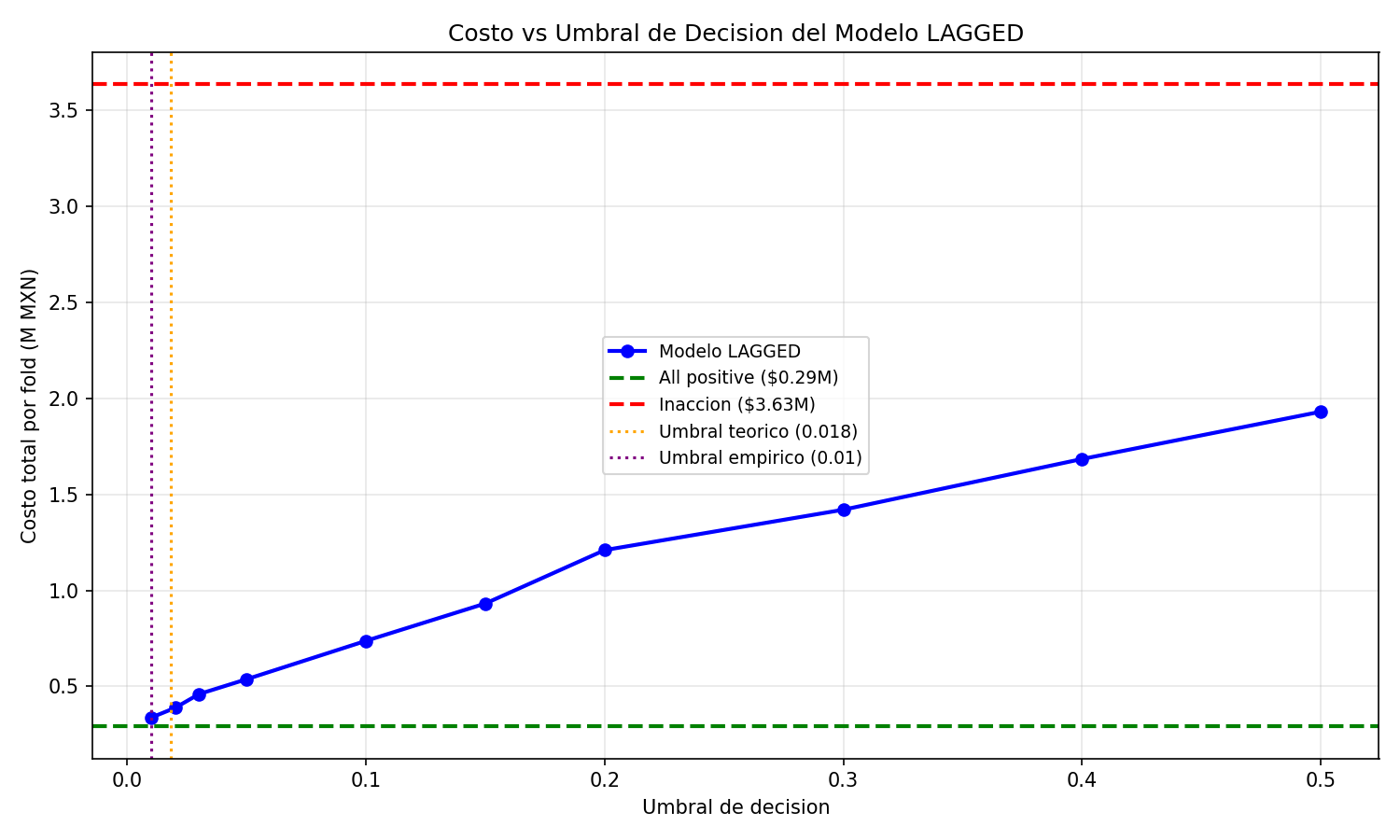

In [12]:
from IPython.display import Image
Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "threshold_sweep.png"), width=800)

### Conclusion del Dia 1

> Con ratio de costos 53:1 entre quiebre no detectado y transferencia
> innecesaria, `all_positive` (transferir siempre) es Pareto-optimo
> bajo capacidad logistica ilimitada. Ningun umbral del modelo LightGBM
> supera esta estrategia: la curva costo-vs-umbral es monotonamente
> creciente, convergiendo a `all_positive` desde arriba. Esto no es
> debilidad del modelo, es propiedad estructural del regimen de costos.
> El valor diferencial del sistema completo emerge cuando se introducen
> restricciones operativas realistas (capacidad logistica limitada),
> donde el modelo se vuelve necesario para priorizar entre alertas
> concurrentes. Esta simulacion es objeto del Dia 2.

**Headline:**

> Con 3 transferencias/dia por CEDI, el sistema necesita priorizar.
> El modelo asigna probabilidades que permiten al agente atender
> primero los SKU-CEDI con mayor riesgo economico -- esa priorizacion
> es el valor diferencial vs una regla de 'transferir todo'.